          order_id order_date  ship_date       ship_mode    customer_name  \
0     AG-2011-2040 2011-01-01 2011-06-01  Standard Class  Toby Braunhardt   
1    IN-2011-47883 2011-01-01 2011-08-01  Standard Class      Joseph Holt   
2     HU-2011-1220 2011-01-01 2011-05-01    Second Class    Annie Thurman   
3  IT-2011-3647632 2011-01-01 2011-05-01    Second Class     Eugene Moren   
4    IN-2011-47883 2011-01-01 2011-08-01  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name  sales  quantity  \
0  Office Supplies      Storage          Tenex 

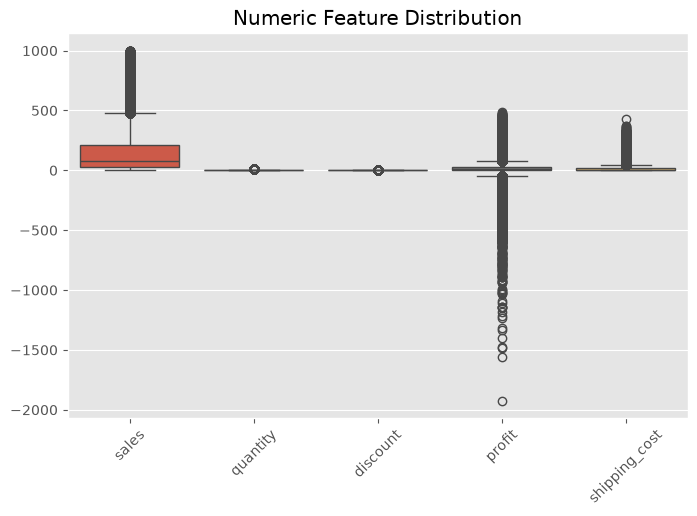

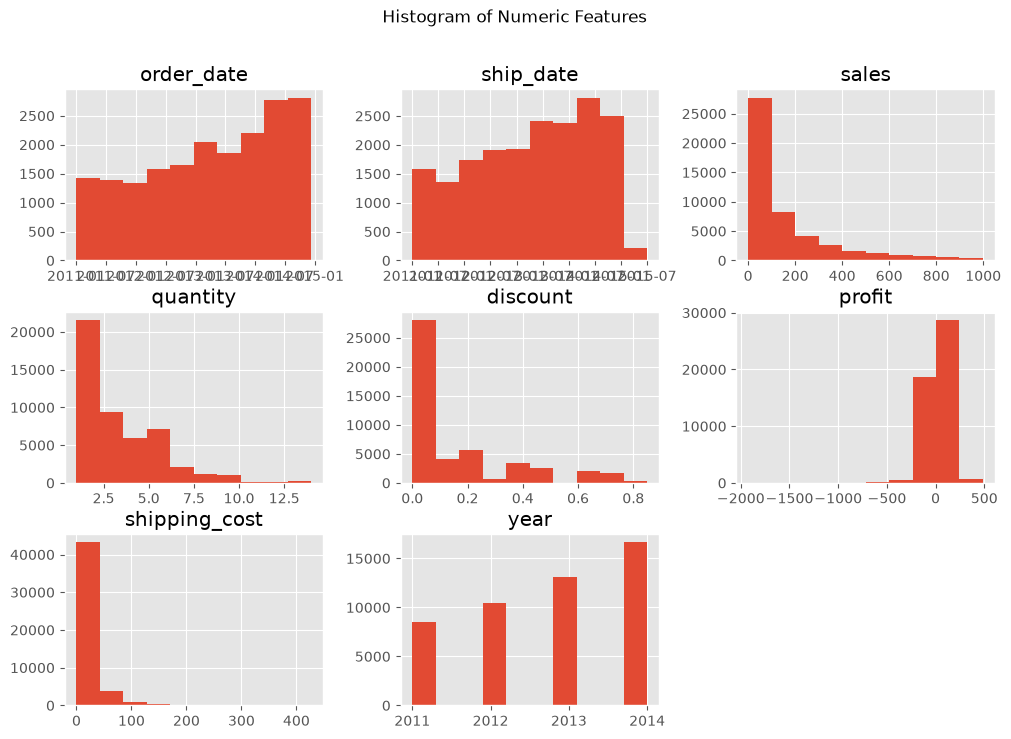

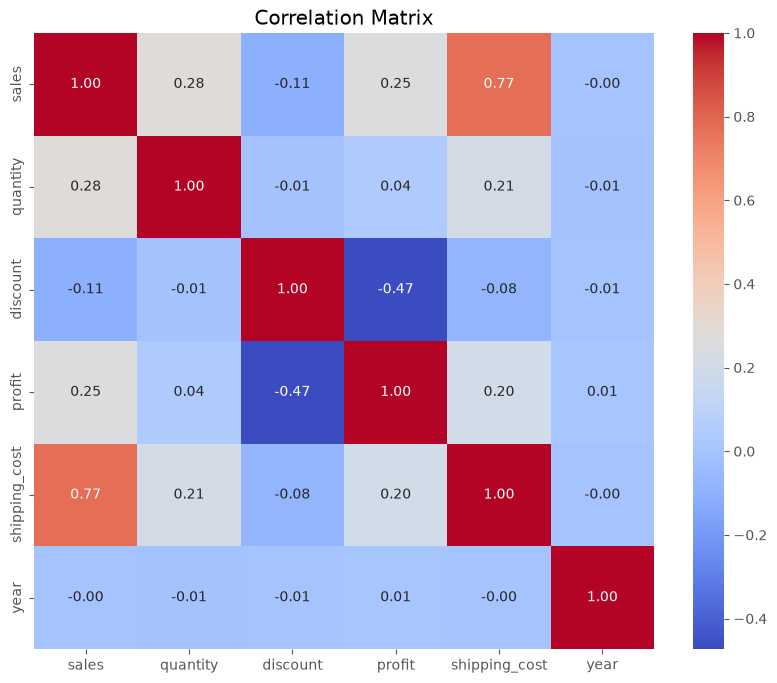

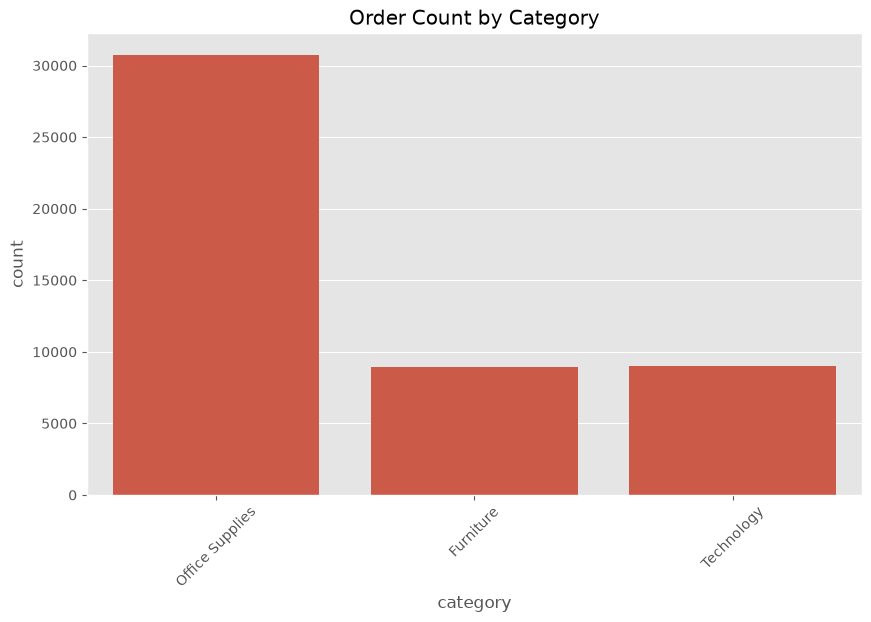

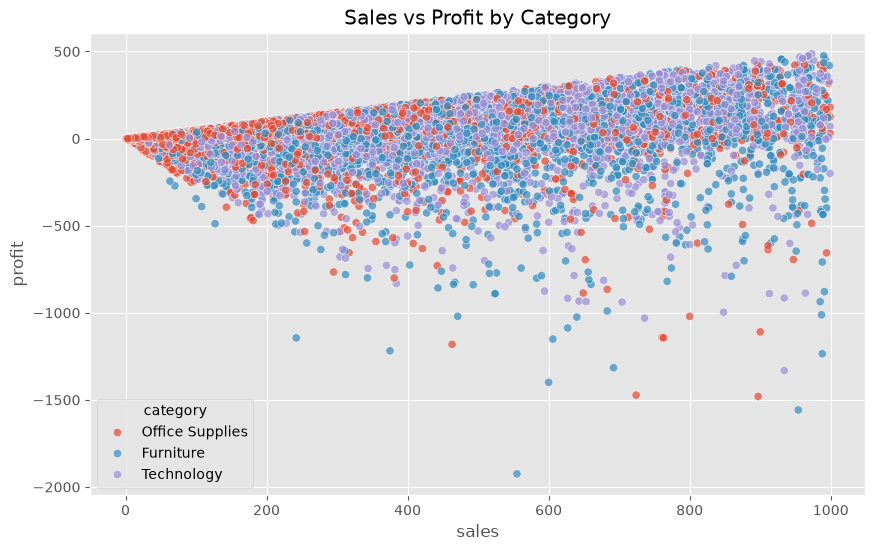

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
df = pd.read_csv("superstoreorders.csv")
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["discount"] = pd.to_numeric(df["discount"], errors="coerce")
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")
df["shipping_cost"] = pd.to_numeric(df["shipping_cost"], errors="coerce")
for col in ["order_date", "ship_date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
print(df.head())
print(df.info())
print(df.describe(include="all"))
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
print("duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
df = df.dropna(subset=["sales", "quantity", "profit"])
df.fillna(df.mean(numeric_only=True), inplace=True)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["sales", "quantity", "discount", "profit", "shipping_cost"]])
plt.xticks(rotation=45)
plt.title("Numeric Feature Distribution")
plt.show()
df.hist(figsize=(12, 8))
plt.suptitle("Histogram of Numeric Features")
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
plt.figure(figsize=(10, 6))
sns.countplot(x="category", data=df)
plt.xticks(rotation=45)
plt.title("Order Count by Category")
plt.show()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="sales", y="profit", hue="category", alpha=0.7)
plt.title("Sales vs Profit by Category")
plt.show()
